# Solar System (2D heliocentric) — minimal viewer

- 2D position in the ecliptic plane (heliocentric)
- Default date/time: now (UTC)
- Parameters: optional target date/time + visible planets (list)
- Labels: initial; if it collides, uses 2 letters (ME/MA)


In [154]:
%pip -q install numpy matplotlib skyfield pyyaml pandas

import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

from skyfield.api import load

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)


Note: you may need to restart the kernel to use updated packages.
Python: 3.13.12
numpy: 2.4.4
matplotlib: 3.10.8


In [160]:
# === Config (YAML) ===
from pathlib import Path

import yaml

CFG_PATH = Path("viewer_config.yaml")

_DEFAULTS = {
    "target_date": "",
    "target_time": "",
    "planets_to_show": ["Jupiter", "Saturn", "Uranus", "Neptune"],
    "lim_au": 50,
    "show_circular_orbits": False,
    # Minor bodies (optional)
    "dwarf_planets_to_show": [],
    "show_main_belt": False,
    "show_jupiter_trojans": False,
    "show_centaurs": False,
    "show_kuiper_belt": False,
    "minor_bodies_total_sample": 5000,
    "main_belt_max": 800,
    "trojans_max": 400,
    "centaurs_max": 400,
    "kuiper_belt_max": 800,
    "minor_bodies_seed": 42,
    "minor_bodies_size": 2.0,
    "minor_bodies_alpha": 0.55,
    "minor_bodies_cache_path": "mpcorb.sample.DAT",
    "mpcorb_reload": False,
}

ALLOWED_DWARF_PLANETS = ["Pluto", "Ceres", "Eris", "Haumea", "Makemake"]

if not CFG_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CFG_PATH.name}. Create it next to this notebook (or adjust CFG_PATH)."
    )

raw = yaml.safe_load(CFG_PATH.read_text(encoding="utf-8")) or {}
if not isinstance(raw, dict):
    raise ValueError(f"{CFG_PATH.name} must contain a YAML mapping/object at the top level")

cfg = {**_DEFAULTS, **raw}

TARGET_DATE = str(cfg.get("target_date", ""))
TARGET_TIME = str(cfg.get("target_time", ""))

PLANETS_TO_SHOW = cfg.get("planets_to_show", [])
if not isinstance(PLANETS_TO_SHOW, list) or not all(isinstance(p, str) for p in PLANETS_TO_SHOW):
    raise ValueError("planets_to_show must be a YAML list of planet name strings")

# Pluto is treated as a dwarf planet; keep it out of planets_to_show.
if any(p.strip().lower() == "pluto" for p in PLANETS_TO_SHOW):
    raise ValueError("Pluto is configured as a dwarf planet here. Move it from planets_to_show to dwarf_planets_to_show.")

LIM_AU = float(cfg.get("lim_au", _DEFAULTS["lim_au"]))
SHOW_CIRCULAR_ORBITS = bool(cfg.get("show_circular_orbits", _DEFAULTS["show_circular_orbits"]))

# Minor bodies toggles
DWARF_PLANETS_TO_SHOW = cfg.get("dwarf_planets_to_show", None)

# Backwards-compat: old boolean key (if present) enables the classic 4 dwarfs.
if DWARF_PLANETS_TO_SHOW is None:
    if bool(cfg.get("show_dwarf_planets", False)):
        DWARF_PLANETS_TO_SHOW = ["Ceres", "Eris", "Haumea", "Makemake"]
    else:
        DWARF_PLANETS_TO_SHOW = []

if not isinstance(DWARF_PLANETS_TO_SHOW, list) or not all(isinstance(p, str) for p in DWARF_PLANETS_TO_SHOW):
    raise ValueError("dwarf_planets_to_show must be a YAML list of dwarf planet name strings")

# Normalize + validate dwarfs.
DWARF_PLANETS_TO_SHOW = [p.strip() for p in DWARF_PLANETS_TO_SHOW if p and str(p).strip()]
invalid_dwarfs = [p for p in DWARF_PLANETS_TO_SHOW if p not in ALLOWED_DWARF_PLANETS]
if invalid_dwarfs:
    raise ValueError(
        "Invalid dwarf planet names in dwarf_planets_to_show: "
        + ", ".join(invalid_dwarfs)
        + "\nAllowed: "
        + ", ".join(ALLOWED_DWARF_PLANETS)
    )

# De-dupe (keep order)
_seen = set()
DWARF_PLANETS_TO_SHOW = [p for p in DWARF_PLANETS_TO_SHOW if not (p in _seen or _seen.add(p))]

SHOW_MAIN_BELT = bool(cfg.get("show_main_belt", _DEFAULTS["show_main_belt"]))
SHOW_JUPITER_TROJANS = bool(cfg.get("show_jupiter_trojans", _DEFAULTS["show_jupiter_trojans"]))
SHOW_CENTAURS = bool(cfg.get("show_centaurs", _DEFAULTS["show_centaurs"]))

# Migration aliases (old keys): show_tno/tno_max
if "show_kuiper_belt" not in raw and "show_tno" in raw:
    print("Config: 'show_tno' is deprecated; use 'show_kuiper_belt'.")
if "kuiper_belt_max" not in raw and "tno_max" in raw:
    print("Config: 'tno_max' is deprecated; use 'kuiper_belt_max'.")

SHOW_KUIPER_BELT = bool(cfg.get("show_kuiper_belt", cfg.get("show_tno", _DEFAULTS["show_kuiper_belt"])))

MINOR_BODIES_TOTAL_SAMPLE = int(cfg.get("minor_bodies_total_sample", _DEFAULTS["minor_bodies_total_sample"]))
MAIN_BELT_MAX = int(cfg.get("main_belt_max", _DEFAULTS["main_belt_max"]))
TROJANS_MAX = int(cfg.get("trojans_max", _DEFAULTS["trojans_max"]))
CENTAURS_MAX = int(cfg.get("centaurs_max", _DEFAULTS["centaurs_max"]))
KUIPER_BELT_MAX = int(cfg.get("kuiper_belt_max", cfg.get("tno_max", _DEFAULTS["kuiper_belt_max"])))
MINOR_BODIES_SEED = int(cfg.get("minor_bodies_seed", _DEFAULTS["minor_bodies_seed"]))

MINOR_BODIES_SIZE = float(cfg.get("minor_bodies_size", _DEFAULTS["minor_bodies_size"]))
MINOR_BODIES_ALPHA = float(cfg.get("minor_bodies_alpha", _DEFAULTS["minor_bodies_alpha"]))
MINOR_BODIES_CACHE_PATH = Path(str(cfg.get("minor_bodies_cache_path", _DEFAULTS["minor_bodies_cache_path"])))
MPCORB_RELOAD = bool(cfg.get("mpcorb_reload", _DEFAULTS["mpcorb_reload"]))

if LIM_AU <= 0:
    raise ValueError("lim_au must be > 0")

for key, value in [
    ("minor_bodies_total_sample", MINOR_BODIES_TOTAL_SAMPLE),
    ("main_belt_max", MAIN_BELT_MAX),
    ("trojans_max", TROJANS_MAX),
    ("centaurs_max", CENTAURS_MAX),
    ("kuiper_belt_max", KUIPER_BELT_MAX),
    ("minor_bodies_seed", MINOR_BODIES_SEED),
]:
    if value < 0:
        raise ValueError(f"{key} must be >= 0")

if not (0.0 <= MINOR_BODIES_ALPHA <= 1.0):
    raise ValueError("minor_bodies_alpha must be in [0, 1]")
if MINOR_BODIES_SIZE < 0:
    raise ValueError("minor_bodies_size must be >= 0")


In [156]:
# === Ephemeris + core functions ===

import zlib

import pandas as pd
from skyfield.constants import GM_SUN_Pitjeva_2005_km3_s2 as GM_SUN
from skyfield.data import mpc

ts = load.timescale()
# DE421 spans ~1900–2050 and is enough for v1.
eph = load("de421.bsp")

sun = eph["sun"]
PLUTO_BODY = eph["pluto barycenter"]

# Each entry is a nested object so you can extend parameters per planet.
BODIES = {
    "Mercury": {"body": eph["mercury"]},
    "Venus": {"body": eph["venus"]},
    "Earth": {"body": eph["earth"]},
    "Mars": {"body": eph["mars"]},
    "Jupiter": {"body": eph["jupiter barycenter"]},
    "Saturn": {"body": eph["saturn barycenter"]},
    "Uranus": {"body": eph["uranus barycenter"]},
    "Neptune": {"body": eph["neptune barycenter"]},
}

ALLOWED_PLANETS = list(BODIES.keys())


def parse_target_datetime(date_str: str, time_str: str) -> datetime:
    """Return a timezone-aware datetime in UTC.

    - If TARGET_DATE or TARGET_TIME is empty, falls back to now (UTC).
    - Otherwise expects 'YYYY-MM-DD' and 'HH:MM'.
    """
    now = datetime.now(timezone.utc)
    if not date_str or not time_str:
        return now

    try:
        year, month, day = (int(x) for x in date_str.split("-"))
        hour, minute = (int(x) for x in time_str.split(":"))
        return datetime(year, month, day, hour, minute, tzinfo=timezone.utc)
    except Exception as e:
        raise ValueError(
            "Invalid format. Use TARGET_DATE='YYYY-MM-DD' and TARGET_TIME='HH:MM' (UTC), "
            "or leave them empty to use the current date/time."
        ) from e


def make_labels(names: list[str]) -> dict[str, str]:
    """Short labels: 1 letter; if it collides, 2 letters; if still collides, numeric suffix."""
    cleaned = [n.strip() for n in names]

    def base1(n: str) -> str:
        return (n[:1] or "?").upper()

    def base2(n: str) -> str:
        return (n[:2] or "??").upper()

    labels = {n: base1(n) for n in cleaned}
    inv: dict[str, list[str]] = {}
    for n, lab in labels.items():
        inv.setdefault(lab, []).append(n)

    # Resolve collisions with 2 letters
    for lab, ns in inv.items():
        if len(ns) > 1:
            for n in ns:
                labels[n] = base2(n)

    inv2: dict[str, list[str]] = {}
    for n, lab in labels.items():
        inv2.setdefault(lab, []).append(n)

    # If still collisions, add deterministic suffix 1..N
    for lab, ns in inv2.items():
        if len(ns) > 1:
            for i, n in enumerate(sorted(ns), start=1):
                labels[n] = f"{lab}{i}"

    return labels


def get_positions_au(t, planet_names: list[str]) -> dict[str, tuple[float, float]]:
    positions: dict[str, tuple[float, float]] = {}
    for name in planet_names:
        body = BODIES[name]["body"]
        x, y, _z = (body - sun).at(t).ecliptic_position().au
        positions[name] = (float(x), float(y))
    return positions


def get_dynamic_circular_orbits_au(positions: dict[str, tuple[float, float]]) -> dict[str, float]:
    """Return circle radii (AU) that pass through each planet's current position."""
    return {name: float(np.hypot(x, y)) for name, (x, y) in positions.items()}


def _find_mpcorb_data_line(data_lines: list[bytes], name: str) -> bytes | None:
    needle = name.lower().encode("ascii", errors="ignore")
    if not needle:
        return None
    for line in data_lines:
        if needle in line.lower():
            return line
    return None


def _build_mpcorb_excerpt(
    path: Path,
    n_sample: int,
    seed: int,
    reload: bool,
    required_names: list[str] | None = None,
) -> None:
    """Create a small MPCORB excerpt for quick loading.

    Uses Skyfield's cache for MPCORB.DAT.gz, then writes a sampled plain-text file.

    If required_names is provided, ensures those named objects are included in the excerpt
    (in addition to the random sample).
    """
    if n_sample <= 0:
        raise ValueError("minor_bodies_total_sample must be > 0 when minor bodies are enabled")

    # Download (once) + cache; returns gz-compressed bytes.
    data_gz = load.open(mpc.MPCORB_URL, reload=reload).read()
    data = zlib.decompress(data_gz, wbits=zlib.MAX_WBITS | 16)
    lines = data.splitlines()

    # Drop the MPCORB header (Skyfield docs: first 43 lines are non-data).
    if len(lines) <= 43:
        raise ValueError("MPCORB file too short/unexpected format")
    data_lines = lines[43:]

    rng = np.random.default_rng(seed)
    n = min(int(n_sample), len(data_lines))
    idx = rng.choice(len(data_lines), size=n, replace=False)
    selected = [data_lines[i] for i in idx]
    selected_set = set(selected)

    if required_names:
        for name in required_names:
            line = _find_mpcorb_data_line(data_lines, name)
            if line is None:
                raise ValueError(f"Could not find required '{name}' in MPCORB catalog")
            if line not in selected_set:
                selected.append(line)
                selected_set.add(line)

    path.write_bytes(b"".join(line + b"\n" for line in selected))


def _df_contains_name(df: pd.DataFrame, name: str) -> bool:
    if "designation" not in df.columns:
        return False
    return bool(df["designation"].astype(str).str.contains(name, case=False, na=False).any())


def load_minor_planets_excerpt(
    excerpt_path: Path,
    n_sample: int,
    seed: int,
    reload: bool = False,
    required_names: list[str] | None = None,
) -> pd.DataFrame:
    """Load a small minor-planet dataframe from an MPCORB excerpt file."""
    if (not excerpt_path.exists()) or reload:
        _build_mpcorb_excerpt(
            excerpt_path,
            n_sample=n_sample,
            seed=seed,
            reload=reload,
            required_names=required_names,
        )

    with load.open(str(excerpt_path)) as f:
        df = mpc.load_mpcorb_dataframe(f)

    # Avoid ill-defined orbits that can raise EphemerisRangeError.
    if "semimajor_axis_au" in df.columns:
        df = df[df.semimajor_axis_au.notnull()]

    # Make lookups simpler and stable.
    if "designation" in df.columns:
        df = df.set_index("designation", drop=False)

    # If a cached excerpt is missing required objects, rebuild it deterministically.
    if required_names:
        missing = [n for n in required_names if not _df_contains_name(df, n)]
        if missing:
            _build_mpcorb_excerpt(
                excerpt_path,
                n_sample=n_sample,
                seed=seed,
                reload=reload,
                required_names=required_names,
            )
            with load.open(str(excerpt_path)) as f:
                df = mpc.load_mpcorb_dataframe(f)
            if "semimajor_axis_au" in df.columns:
                df = df[df.semimajor_axis_au.notnull()]
            if "designation" in df.columns:
                df = df.set_index("designation", drop=False)

    return df


def _find_minor_row_by_name(df: pd.DataFrame, name: str) -> pd.Series:
    if "designation" not in df.columns:
        raise ValueError("Minor planets dataframe missing 'designation' column")

    mask = df["designation"].astype(str).str.contains(name, case=False, na=False)
    matches = df[mask]
    if matches.empty:
        raise ValueError(
            f"Could not find '{name}' in MPCORB excerpt. "
            "Set mpcorb_reload=true or increase minor_bodies_total_sample."
        )
    # Deterministic: pick the first match by index.
    return matches.sort_index().iloc[0]


def build_dwarf_bodies(df: pd.DataFrame, dwarf_names: list[str]) -> dict[str, object]:
    """Return vector functions for named dwarf planets using MPCORB elements."""
    bodies: dict[str, object] = {}
    for name in dwarf_names:
        row = _find_minor_row_by_name(df, name)
        bodies[name] = sun + mpc.mpcorb_orbit(row, ts, GM_SUN)
    return bodies


def sample_minor_group(
    df: pd.DataFrame,
    *,
    a_min: float,
    a_max: float | None,
    n_max: int,
    seed: int,
    strict: bool = False,
) -> pd.DataFrame:
    if n_max <= 0:
        return df.iloc[0:0]
    if "semimajor_axis_au" not in df.columns:
        return df.iloc[0:0]
    a = df.semimajor_axis_au
    if a_max is None:
        subset = df[a > a_min] if strict else df[a >= a_min]
    else:
        if strict:
            subset = df[(a > a_min) & (a < a_max)]
        else:
            subset = df[(a >= a_min) & (a <= a_max)]
    if subset.empty:
        return subset
    n = min(int(n_max), len(subset))
    return subset.sample(n=n, random_state=int(seed))


def positions_for_minor_df(t, df: pd.DataFrame) -> np.ndarray:
    """Return Nx2 array of (x, y) AU for a dataframe of minor-planet orbits."""
    if df.empty:
        return np.zeros((0, 2), dtype=float)

    xs: list[float] = []
    ys: list[float] = []
    skipped = 0
    for _idx, row in df.iterrows():
        try:
            obj = sun + mpc.mpcorb_orbit(row, ts, GM_SUN)
            x, y, _z = (obj - sun).at(t).ecliptic_position().au
        except Exception:
            skipped += 1
            continue
        xs.append(float(x))
        ys.append(float(y))
    if skipped:
        print(f"Skipped {skipped} minor-body rows due to invalid orbital elements.")
    return np.column_stack([xs, ys])


def plot_solar(
    dt_utc: datetime,
    positions: dict[str, tuple[float, float]],
    labels: dict[str, str],
    lim_au: float,
    circular_orbits_au: dict[str, float] | None = None,
    dwarf_positions: dict[str, tuple[float, float]] | None = None,
    minor_clouds: dict[str, np.ndarray] | None = None,
    minor_alpha: float = 0.55,
    minor_size: float = 2.0,
    show_minor_legend: bool = True,
    show_dwarf_legend: bool = True,
 ):
    fig, ax = plt.subplots(figsize=(7.6, 6.0), dpi=140)
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    sun_color = "#ffdd00"
    planet_color = "#ff4040"
    cmap = plt.get_cmap("tab10")
    dwarf_color = cmap(3)

    # Orbits (optional)
    if circular_orbits_au:
        for _name, r in circular_orbits_au.items():
            ax.add_patch(
                plt.Circle(
                    (0, 0),
                    r,
                    fill=False,
                    edgecolor="white",
                    linewidth=1,
                    alpha=0.12,
                    zorder=2,
                )
            )

    # Minor clouds (optional; behind planets)
    if minor_clouds:
        for i, (group, xy) in enumerate(minor_clouds.items()):
            if xy.size == 0:
                continue
            ax.scatter(
                xy[:, 0],
                xy[:, 1],
                s=minor_size,
                c=[cmap((i + 4) % 10)],
                alpha=minor_alpha,
                edgecolors="none",
                zorder=1,
            )

    # Sun
    ax.scatter([0], [0], s=120, c=sun_color, edgecolors="none", zorder=5)

    # Planets
    for name, (x, y) in positions.items():
        ax.scatter([x], [y], s=34, c=planet_color, zorder=6)
        ax.text(
            x,
            y,
            labels.get(name, name[:1].upper()),
            color="white",
            fontsize=14,
            ha="left",
            va="bottom",
            fontweight="bold",
            zorder=7,
        )

    # Dwarf planets (optional; labeled)
    if dwarf_positions:
        for name, (x, y) in dwarf_positions.items():
            ax.scatter([x], [y], s=22, c=[dwarf_color], zorder=6)
            ax.text(
                x,
                y,
                labels.get(name, name[:1].upper()),
                color="white",
                fontsize=13,
                ha="left",
                va="bottom",
                fontweight="bold",
                zorder=7,
            )

    # Simple color legend
    from matplotlib.lines import Line2D

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            label="Sun",
            markerfacecolor=sun_color,
            markeredgecolor="none",
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            label="Planets",
            markerfacecolor=planet_color,
            markeredgecolor="none",
            markersize=7,
        ),
    ]
    if dwarf_positions and show_dwarf_legend:
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                label="Dwarf planets",
                markerfacecolor=dwarf_color,
                markeredgecolor="none",
                markersize=6,
            )
        )
    if circular_orbits_au:
        handles.append(Line2D([0], [0], color="white", linewidth=1, alpha=0.4, label="Circular orbits"))
    if minor_clouds and show_minor_legend:
        # Add entries in the same order we plotted
        for i, group in enumerate(minor_clouds.keys()):
            handles.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="None",
                    label=group,
                    markerfacecolor=cmap((i + 4) % 10),
                    markeredgecolor="none",
                    markersize=5,
                    alpha=minor_alpha,
                )
            )

    # Put legend below the plot so it doesn't cover positions
    fig.subplots_adjust(bottom=0.22)
    leg = fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=3,
        frameon=True,
    )
    leg.get_frame().set_facecolor("black")
    leg.get_frame().set_edgecolor("white")
    for txt in leg.get_texts():
        txt.set_color("white")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim_au, lim_au)
    ax.set_ylim(-lim_au, lim_au)

    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")

    ax.set_xlabel("AU", color="white")
    ax.set_ylabel("AU", color="white")
    ax.set_title(
        f"Solar System (heliocentric, ecliptic) — {dt_utc.isoformat(timespec='minutes')}",
        color="white",
    )

    plt.show()


Centaurs sample check: a in (8.304, 29.938) AU; q in (5.722, 28.471) AU
Kuiper Belt sample check: semimajor axis a in (30.185, 49.634) AU
Skipped 6 minor-body rows due to invalid orbital elements.


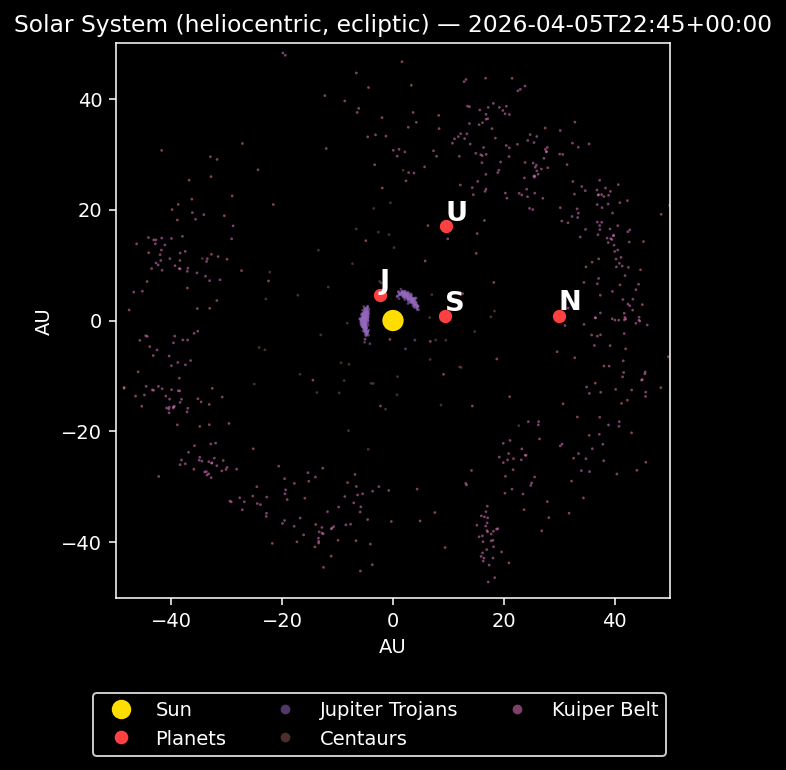

In [161]:
# === Run ===

dt_utc = parse_target_datetime(TARGET_DATE, TARGET_TIME)

invalid = [p for p in PLANETS_TO_SHOW if p not in BODIES]
if invalid:
    raise ValueError(
        "Invalid planet names in PLANETS_TO_SHOW: "
        + ", ".join(invalid)
        + "\nAllowed: "
        + ", ".join(ALLOWED_PLANETS)
    )

# Skyfield: convert UTC datetime to a Skyfield Time
t = ts.utc(
    dt_utc.year,
    dt_utc.month,
    dt_utc.day,
    dt_utc.hour,
    dt_utc.minute,
    dt_utc.second,
 )

# Major planets
positions = get_positions_au(t, PLANETS_TO_SHOW)

# Optional circular orbits (major planets)
orbits_au = get_dynamic_circular_orbits_au(positions) if SHOW_CIRCULAR_ORBITS else None

# Minor bodies (optional)
minor_enabled = (
    bool(DWARF_PLANETS_TO_SHOW)
    or SHOW_MAIN_BELT
    or SHOW_JUPITER_TROJANS
    or SHOW_CENTAURS
    or SHOW_KUIPER_BELT
 )
minor_df = None
dwarf_positions = None
minor_clouds = None

if minor_enabled:
    excerpt_path = MINOR_BODIES_CACHE_PATH
    if not excerpt_path.is_absolute():
        excerpt_path = Path.cwd() / excerpt_path

    required_minor = [n for n in DWARF_PLANETS_TO_SHOW if n != "Pluto"]
    minor_df = load_minor_planets_excerpt(
        excerpt_path,
        n_sample=MINOR_BODIES_TOTAL_SAMPLE,
        seed=MINOR_BODIES_SEED,
        reload=MPCORB_RELOAD,
        required_names=required_minor or None,
    )

    # Dwarfs (named; selected individually)
    if DWARF_PLANETS_TO_SHOW:
        dwarf_positions = {}
        if "Pluto" in DWARF_PLANETS_TO_SHOW:
            x, y, _z = (PLUTO_BODY - sun).at(t).ecliptic_position().au
            dwarf_positions["Pluto"] = (float(x), float(y))

        other_dwarfs = [n for n in DWARF_PLANETS_TO_SHOW if n != "Pluto"]
        if other_dwarfs:
            dwarf_bodies = build_dwarf_bodies(minor_df, other_dwarfs)
            for name, obj in dwarf_bodies.items():
                x, y, _z = (obj - sun).at(t).ecliptic_position().au
                dwarf_positions[name] = (float(x), float(y))

    # Clouds (many dots; no labels)
    clouds: dict[str, np.ndarray] = {}
    if SHOW_MAIN_BELT:
        df_mb = sample_minor_group(
            minor_df, a_min=2.0, a_max=3.5, n_max=MAIN_BELT_MAX, seed=MINOR_BODIES_SEED + 1
        )
        clouds["Main belt"] = positions_for_minor_df(t, df_mb)
    if SHOW_JUPITER_TROJANS:
        df_tr = sample_minor_group(
            minor_df, a_min=4.8, a_max=5.4, n_max=TROJANS_MAX, seed=MINOR_BODIES_SEED + 2
        )
        clouds["Jupiter Trojans"] = positions_for_minor_df(t, df_tr)
    if SHOW_CENTAURS:
        if "semimajor_axis_au" in minor_df.columns and "eccentricity" in minor_df.columns:
            a = minor_df.semimajor_axis_au
            e = minor_df.eccentricity
            q = a * (1.0 - e)
            subset = minor_df[a.notnull() & e.notnull()]
            a2 = subset.semimajor_axis_au
            e2 = subset.eccentricity
            q2 = a2 * (1.0 - e2)
            mask = (a2 > 5.5) & (a2 < 30.0) & (q2 > 5.5) & (q2 < 30.0)
            subset = subset[mask]
            if not subset.empty and CENTAURS_MAX > 0:
                n = min(int(CENTAURS_MAX), len(subset))
                df_cent = subset.sample(n=n, random_state=int(MINOR_BODIES_SEED + 3))
            else:
                df_cent = subset.iloc[0:0]
        else:
            df_cent = minor_df.iloc[0:0]

        if not df_cent.empty and "semimajor_axis_au" in df_cent.columns and "eccentricity" in df_cent.columns:
            a_min_actual = float(df_cent.semimajor_axis_au.min())
            a_max_actual = float(df_cent.semimajor_axis_au.max())
            q_cent = df_cent.semimajor_axis_au * (1.0 - df_cent.eccentricity)
            q_min_actual = float(q_cent.min())
            q_max_actual = float(q_cent.max())
            print(
                "Centaurs sample check: "
                f"a in ({a_min_actual:.3f}, {a_max_actual:.3f}) AU; "
                f"q in ({q_min_actual:.3f}, {q_max_actual:.3f}) AU"
            )
        clouds["Centaurs"] = positions_for_minor_df(t, df_cent)
    if SHOW_KUIPER_BELT:
        df_kb = sample_minor_group(
            minor_df,
            a_min=30.0,
            a_max=50.0,
            n_max=KUIPER_BELT_MAX,
            seed=MINOR_BODIES_SEED + 4,
            strict=True,
        )
        if not df_kb.empty and "semimajor_axis_au" in df_kb.columns:
            a_min_actual = float(df_kb.semimajor_axis_au.min())
            a_max_actual = float(df_kb.semimajor_axis_au.max())
            print(f"Kuiper Belt sample check: semimajor axis a in ({a_min_actual:.3f}, {a_max_actual:.3f}) AU")
        clouds["Kuiper Belt"] = positions_for_minor_df(t, df_kb)
    minor_clouds = clouds if clouds else None

# Labels only for major planets + (optional) dwarfs
label_names = list(PLANETS_TO_SHOW) + (list(dwarf_positions.keys()) if dwarf_positions else [])
labels = make_labels(label_names)

plot_solar(
    dt_utc,
    positions,
    labels,
    LIM_AU,
    circular_orbits_au=orbits_au,
    dwarf_positions=dwarf_positions,
    minor_clouds=minor_clouds,
    minor_alpha=MINOR_BODIES_ALPHA,
    minor_size=MINOR_BODIES_SIZE,
 )
